# 📊 E-Commerce Business Intelligence Suite

## Project Objective

This project analyzes customer behavior, revenue trends, product performance, delivery efficiency, and customer satisfaction using the Brazilian Olist E-Commerce dataset.

### Business Questions
- How much revenue does the business generate?
- Which product categories contribute the most revenue?
- Where are the customers located?
- How satisfied are customers?
- How efficient is the delivery process?

## Environment Setup

Importing required Python libraries for data analysis and visualization.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Data Loading

Loading all datasets required for customer, order, payment, product, review, and seller analysis.

In [22]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Order Items:", order_items.shape)
print("Sellers:", sellers.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)
Order Items: (112650, 7)
Sellers: (3095, 4)


## Sample Data Inspection

Displaying a sample of customer records to understand the available features and structure.

In [23]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## Dataset Overview

Checking the size and dimensions of each dataset to understand the volume of available business data.

In [24]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Order Items:", order_items.shape)
print("Sellers:", sellers.shape)


Customers: (99441, 5)
Orders: (99441, 8)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)
Order Items: (112650, 7)
Sellers: (3095, 4)


## Data Quality Assessment

Identifying missing values in the dataset before performing business analysis.

In [25]:
orders.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_estimated_delivery_date       0
dtype: int64

## Revenue Analysis

Calculating the total revenue generated from all completed customer payments.

In [26]:
total_revenue = payments["payment_value"].sum()

print("Total Revenue: R$", round(total_revenue, 2))

Total Revenue: R$ 16008872.12


## Revenue Trend Analysis

Analyzing how business revenue changed over time and identifying growth patterns.

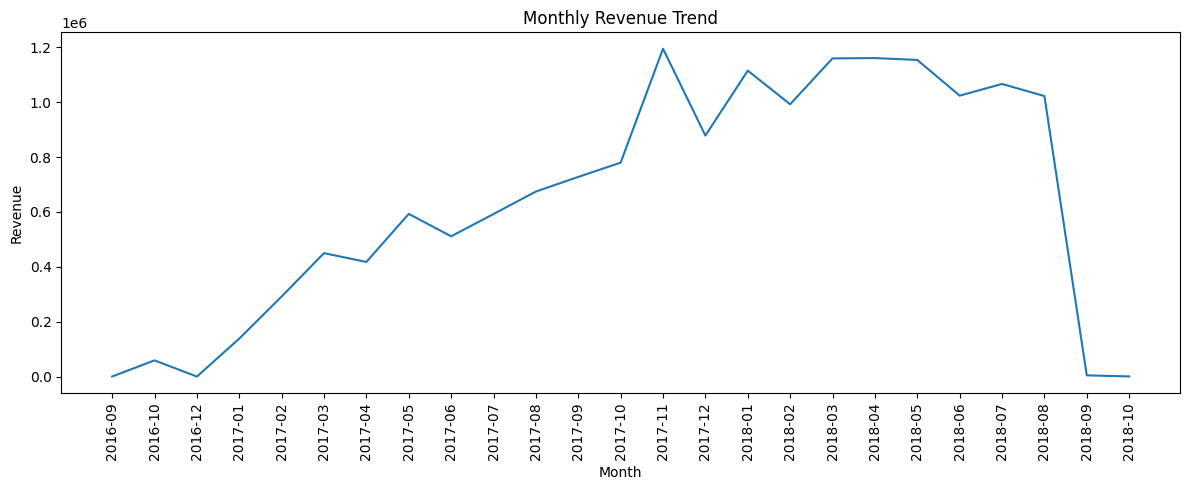

In [27]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

monthly_revenue = orders.merge(
    payments,
    on="order_id"
)

monthly_revenue["month"] = (
    monthly_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

revenue_by_month = (
    monthly_revenue.groupby("month")["payment_value"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,5))
sns.lineplot(
    data=revenue_by_month,
    x="month",
    y="payment_value"
)

plt.xticks(rotation=90)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

## Best Performing Months

Identifying the months that generated the highest revenue for the business.

In [28]:
revenue_by_month.sort_values(
    "payment_value",
    ascending=False
).head(10)

,month,payment_value
13,2017-11,1194882.80
18,2018-04,1160785.48
17,2018-03,1159652.12
19,2018-05,1153982.15
15,2018-01,1115004.18
21,2018-07,1066540.75
20,2018-06,1023880.50
22,2018-08,1022425.32
16,2018-02,992463.34
14,2017-12,878401.48


## Product Performance Analysis

Evaluating which product categories contribute the most to overall business revenue.

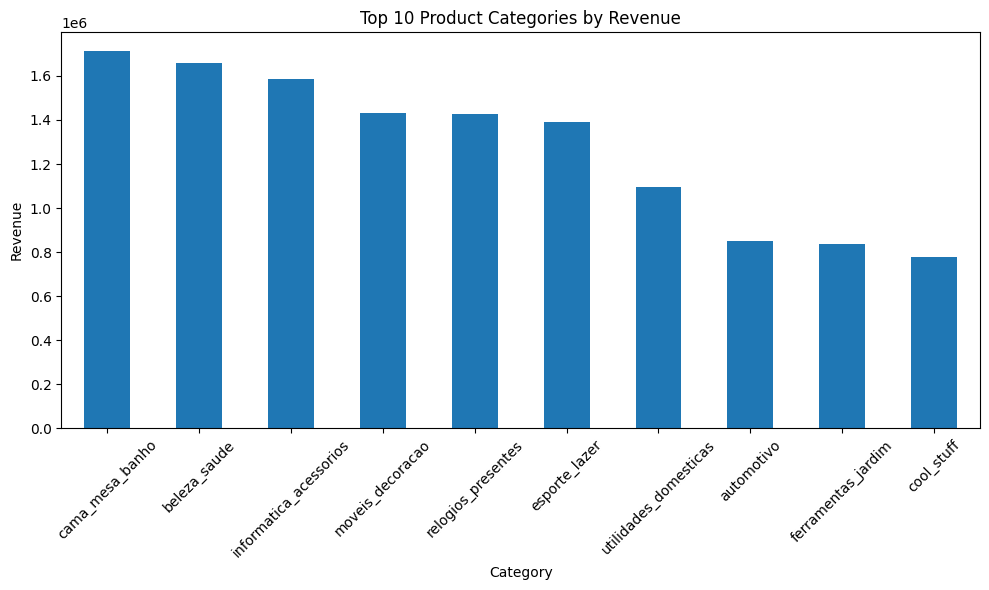

In [29]:
category_sales = (
    order_items
    .merge(products, on="product_id")
    .merge(payments[["order_id", "payment_value"]], on="order_id")
)

top_categories = (
    category_sales.groupby("product_category_name")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_categories.plot(kind="bar")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Geographic Customer Analysis

Understanding customer distribution across different states and regions.

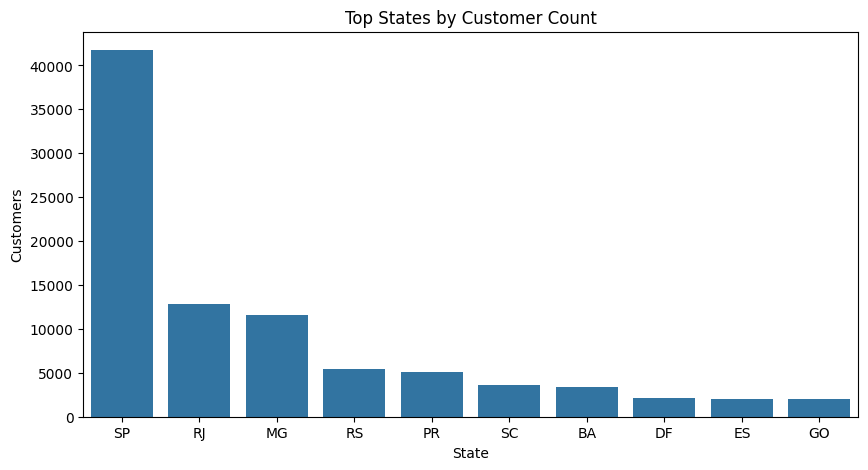

In [30]:
state_counts = customers["customer_state"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=state_counts.index,
    y=state_counts.values
)

plt.title("Top States by Customer Count")
plt.xlabel("State")
plt.ylabel("Customers")
plt.show()

## Customer Concentration

Examining the states with the largest customer populations.

In [31]:
customers["customer_state"].value_counts().head(15)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
Name: count, dtype: int64

## Customer Satisfaction Metrics

Analyzing review score frequencies to evaluate overall customer satisfaction.

In [32]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

## Review Score Distribution

Visualizing customer feedback patterns and satisfaction levels.

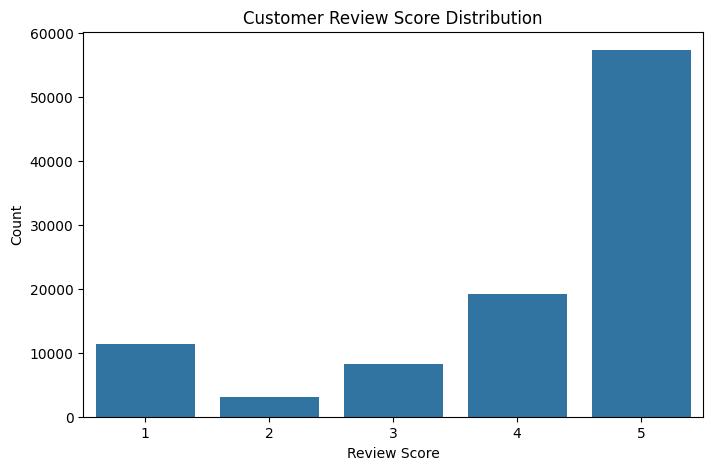

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(x="review_score", data=reviews)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

## Delivery Performance Analysis

Calculating delivery duration and evaluating logistics efficiency.

In [34]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

## Business KPI: Total Orders

Measuring the total number of unique orders processed by the platform.

In [35]:
total_orders = orders["order_id"].nunique()
print("Total Orders:", total_orders)

Total Orders: 99441


## Business KPI: Total Customers

Calculating the total number of unique customers served.

In [36]:
total_customers = customers["customer_unique_id"].nunique()
print("Total Customers:", total_customers)

Total Customers: 96096


## Business KPI: Average Order Value

Determining the average revenue generated per customer order.

In [37]:
avg_order_value = payments["payment_value"].mean()
print("Average Order Value: R$", round(avg_order_value, 2))

Average Order Value: R$ 154.1


## Business KPI: Average Customer Rating

Calculating the average customer review score across all transactions.

In [38]:
avg_review = reviews["review_score"].mean()
print("Average Review Score:", round(avg_review, 2))

Average Review Score: 4.09


# Key Business Insights

- Revenue demonstrates a strong growth trend over the analysis period.
- A small number of product categories contribute a significant share of total revenue.
- Customer concentration is highest in a few major states.
- Delivery efficiency directly impacts customer satisfaction.
- Review data indicates generally positive customer experiences.
- Business growth opportunities exist through logistics optimization and targeted regional expansion.

# Conclusion

This analysis provides actionable insights into customer behavior, sales performance, product trends, and operational efficiency. The findings can support data-driven decision making and future business strategy development.